In [1]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 73.7 MB/s eta 0:00:00


## 1. Data Preparation & Explanation

In [2]:
import pandas as pd, numpy as np, time
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv('/content/dataset_model_ready.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df = df[~df['cycle_id'].isin([0, 11])].copy()

# df['원수 탁도'] = df['원수 탁도'].interpolate(method='linear', limit_direction='both')
# df['원수 pH']  = df['원수 pH'].interpolate(method='linear', limit_direction='both')

op = df[df['is_operating'] == True].copy().reset_index(drop=True)

print(f"Operating rows: {len(op)}, cycles used: {sorted(op['cycle_id'].unique())}")
op.head()


Operating rows: 6694, cycles used: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,Date,운영차압,비플럭스,원수 수온,원수 탁도,원수 TDS,원수 전기전도도,원수 pH,유입압력,생산량,is_operating,cycle_id,rain,temp
0,2021-01-01 00:00:01,3.36,5.899170,3.69,0.41,503.730,839.55,7.06,12.04,781.43,True,1,0.0,-6.333053
1,2021-01-01 01:00:01,3.41,5.842618,3.68,0.39,504.048,840.08,7.06,12.15,781.57,True,1,0.0,-6.895429
2,2021-01-01 02:00:01,3.38,5.827946,3.61,0.38,504.732,841.22,7.07,12.16,778.91,True,1,0.0,-8.597189
3,2021-01-01 03:00:01,3.33,5.891886,3.59,0.33,505.524,842.54,7.07,12.08,781.64,True,1,0.0,-8.484225
4,2021-01-01 04:00:01,3.58,5.898117,3.52,0.32,506.148,843.58,7.07,12.17,779.79,True,1,0.0,-9.146757


In [3]:
SF   = op['비플럭스'].values
TDS  = op['원수 TDS'].values
TEMP = op['원수 수온'].values
TURB = op['원수 탁도'].values
CYCLE = op['cycle_id'].values

def z(x):
    return (x - x.mean()) / x.std()

TDS_z, TEMP_z, TURB_z = z(TDS), z(TEMP), z(TURB)
SF_MIN, SF_MAX = SF.min(), SF.max()

cycles = sorted(np.unique(CYCLE))
cycle_idx = {c: np.where(CYCLE == c)[0] for c in cycles}
cycle_start = {c: SF[cycle_idx[c][0]] for c in cycles}

print(f"Specific-flux observed range: [{SF_MIN:.3f}, {SF_MAX:.3f}]")
print(f"Number of usable cycles: {len(cycles)}")


Specific-flux observed range: [3.260, 5.925]
Number of usable cycles: 10


## 2. Problem Formulation


In [4]:
def theta_t(beta):
    b0, b1, b2, b3 = beta
    return b0 + b1*TDS_z + b2*TEMP_z + b3*TURB_z

def is_feasible(beta):
    th = theta_t(beta)
    return th.min() >= SF_MIN and th.max() <= SF_MAX

def simulate(beta):
    th = theta_t(beta)
    total_loss, total_cip, total_time = 0.0, 0, 0.0
    for c in cycles:
        idx = cycle_idx[c]
        sf_c, th_c = SF[idx], th[idx]
        ref = cycle_start[c]
        below = np.where(sf_c < th_c)[0]
        if below.size > 0:
            first = below[0]
            window = slice(0, first + 1)
            T_c = first + 1
            total_cip += 1
        else:
            window = slice(0, len(sf_c))
            T_c = len(sf_c)
        total_loss += np.sum(np.maximum(0.0, ref - sf_c[window]))
        total_time += T_c
    return total_loss, total_cip, total_time

def objective(beta, lam):
    if not is_feasible(beta):
        return 1e9, None, None, None
    loss, cip, t = simulate(beta)
    rate = (loss + lam*cip) / t
    return rate, loss, cip, t


## 3. Algorithm Selection & Greedy Baseline



In [5]:
def greedy_baseline(lam, step=0.01):
    t0 = time.time()
    best = None
    for b0 in np.arange(SF_MIN, SF_MAX, step):
        o, l, c, t = objective([b0, 0, 0, 0], lam)
        if best is None or o < best[0]:
            best = (o, l, c, t, b0)
    elapsed = time.time() - t0
    return {'rate': best[0], 'loss': best[1], 'cip': best[2], 'time_hours': best[3],
            'beta': [best[4], 0, 0, 0], 'runtime_sec': elapsed}

g = greedy_baseline(lam=10)
print(f"Greedy baseline (lambda=10): beta0*={g['beta'][0]:.3f}, rate={g['rate']:.5f}, "
      f"cip={g['cip']}, runtime={g['runtime_sec']:.3f}s")


Greedy baseline (lambda=10): beta0*=4.640, rate=0.22451, cip=9, runtime=0.142s


## 4. Metaheuristic Implementation & Feasibility Check


In [6]:
def tabu_search(lam, step=0.08, tenure=8, max_iter=300, no_improve_limit=40, init_beta=None, seed=0):
    rng = np.random.default_rng(seed)
    if init_beta is None:
        init_beta = np.array([greedy_baseline(lam)['beta'][0], 0.0, 0.0, 0.0])
    cur = np.array(init_beta, dtype=float)
    cur_obj, _, _, _ = objective(cur, lam)
    best, best_obj = cur.copy(), cur_obj

    tabu = {}
    history = [best_obj]
    no_improve = 0

    for it in range(max_iter):
        moves = []
        for dim in range(4):
            for sign in (+1, -1):
                cand = cur.copy()
                cand[dim] += sign*step
                if not is_feasible(cand):
                    continue
                o, _, _, _ = objective(cand, lam)
                is_tabu = tabu.get((dim, sign), -1) > it
                aspiration = o < best_obj
                if is_tabu and not aspiration:
                    continue
                moves.append((o, dim, sign, cand))

        if not moves:
            cand = cur + rng.normal(0, step*3, size=4)
            if is_feasible(cand):
                cur = cand
                cur_obj, _, _, _ = objective(cur, lam)
            history.append(best_obj)
            continue

        moves.sort(key=lambda m: m[0])
        o, dim, sign, cand = moves[0]
        cur, cur_obj = cand, o
        tabu[(dim, -sign)] = it + tenure

        if cur_obj < best_obj - 1e-12:
            best, best_obj = cur.copy(), cur_obj
            no_improve = 0
        else:
            no_improve += 1

        history.append(best_obj)

        if no_improve >= no_improve_limit:
            cand = best + rng.normal(0, step*4, size=4)
            if is_feasible(cand):
                cur = cand
                cur_obj, _, _, _ = objective(cur, lam)
            no_improve = 0

    loss, cip, t = simulate(best)
    return {'rate': best_obj, 'loss': loss, 'cip': cip, 'time_hours': t,
            'beta': best.tolist(), 'history': history}

ts = tabu_search(lam=10)
print(f"Tabu Search (lambda=10): beta*={np.round(ts['beta'],4)}, rate={ts['rate']:.5f}, cip={ts['cip']}")
print(f"Feasible check on final solution: {is_feasible(ts['beta'])}")


Tabu Search (lambda=10): beta*=[ 5.1203  0.16   -0.24    0.    ], rate=0.09404, cip=9
Feasible check on final solution: True


## 5. Parameter Tuning & Sensitivity Analysis



In [7]:
# 1 Parameter tuning: step size (N=12 seeds per setting, mean ± std)
lam_ref = 10
N_SEEDS = 14

print(f"--- Step size sensitivity (tenure=8, max_iter=300, N={N_SEEDS} seeds) ---")
step_results = []
for step in [0.02, 0.05, 0.08, 0.15, 0.30]:
    rates, cips, runtimes = [], [], []
    for seed in range(N_SEEDS):
        t0 = time.time()
        r = tabu_search(lam_ref, step=step, tenure=8, max_iter=300, seed=seed)
        runtimes.append(time.time() - t0)
        rates.append(r['rate'])
        cips.append(r['cip'])
    rates = np.array(rates)
    step_results.append({
        'step': step,
        'rate_mean': rates.mean(), 'rate_std': rates.std(ddof=1),
        'cip_mean': np.mean(cips), 'runtime_mean': np.mean(runtimes)
    })
    print(f"step={step:.2f}: rate={rates.mean():.5f} ± {rates.std(ddof=1):.5f}  "
          f"cip_mean={np.mean(cips):.1f}  runtime_mean={np.mean(runtimes):.2f}s")

print()
print(f"--- Tabu tenure sensitivity (step=0.08, max_iter=300, N={N_SEEDS} seeds) ---")
tenure_results = []
for tenure in [2, 5, 8, 15, 30]:
    rates, cips = [], []
    for seed in range(N_SEEDS):
        r = tabu_search(lam_ref, step=0.08, tenure=tenure, max_iter=300, seed=seed)
        rates.append(r['rate'])
        cips.append(r['cip'])
    rates = np.array(rates)
    tenure_results.append({
        'tenure': tenure,
        'rate_mean': rates.mean(), 'rate_std': rates.std(ddof=1),
        'cip_mean': np.mean(cips)
    })
    print(f"tenure={tenure:3d}: rate={rates.mean():.5f} ± {rates.std(ddof=1):.5f}  cip_mean={np.mean(cips):.1f}")

--- Step size sensitivity (tenure=8, max_iter=300, N=14 seeds) ---
step=0.02: rate=0.09208 ± 0.00134  cip_mean=9.0  runtime_mean=1.02s
step=0.05: rate=0.09207 ± 0.00042  cip_mean=9.0  runtime_mean=0.59s
step=0.08: rate=0.09373 ± 0.00066  cip_mean=9.0  runtime_mean=0.58s
step=0.15: rate=0.09890 ± 0.00011  cip_mean=9.0  runtime_mean=0.45s
step=0.30: rate=0.11790 ± 0.00439  cip_mean=9.9  runtime_mean=0.50s

--- Tabu tenure sensitivity (step=0.08, max_iter=300, N=14 seeds) ---
tenure=  2: rate=0.09729 ± 0.00293  cip_mean=9.0
tenure=  5: rate=0.09758 ± 0.00286  cip_mean=9.0
tenure=  8: rate=0.09373 ± 0.00066  cip_mean=9.0
tenure= 15: rate=0.09457 ± 0.00146  cip_mean=9.0
tenure= 30: rate=0.09499 ± 0.00215  cip_mean=9.0


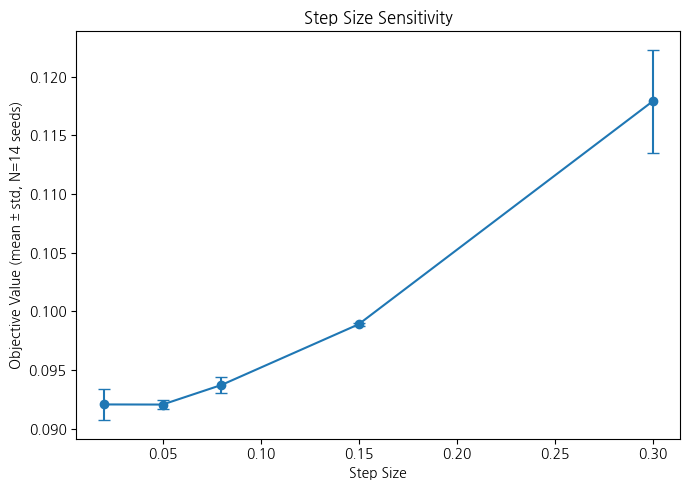

In [8]:
step_x = [result['step'] for result in step_results]
step_y = [result['rate_mean'] for result in step_results]
step_err = [result['rate_std'] for result in step_results]

plt.figure(figsize=(7, 5))
plt.errorbar(step_x, step_y, yerr=step_err, marker='o', capsize=4)
plt.xlabel('Step Size')
plt.ylabel('Objective Value (mean ± std, N=14 seeds)')
plt.title('Step Size Sensitivity')
plt.grid(False)
plt.tight_layout()
plt.show()

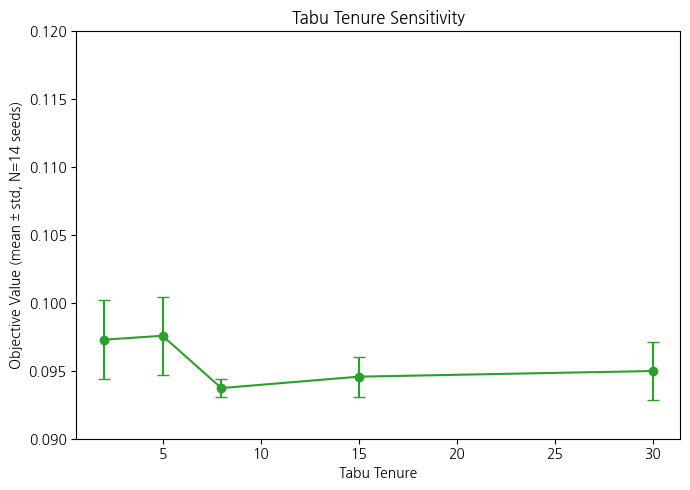

In [9]:
tenure_x = [result['tenure'] for result in tenure_results]
tenure_y = [result['rate_mean'] for result in tenure_results]
tenure_err = [result['rate_std'] for result in tenure_results]

plt.figure(figsize=(7, 5))
plt.errorbar(tenure_x, tenure_y, yerr=tenure_err, marker='o', capsize=4, color='tab:green')
plt.ylim(0.09, 0.12)
plt.xlabel('Tabu Tenure')
plt.ylabel('Objective Value (mean ± std, N=14 seeds)')
plt.title('Tabu Tenure Sensitivity')
plt.grid(False)
plt.tight_layout()
plt.show()

In [10]:
# 2 Lambda sensitivity
lambdas = [1, 5, 10, 30, 50, 80]
N_SEEDS = 14
results = []
convergence_curves = {}

for lam in lambdas:
    g = greedy_baseline(lam)

    rates, cips, runtimes = [], [], []
    for seed in range(N_SEEDS):
        t0 = time.time()
        ts = tabu_search(lam, step=0.08, tenure=8, max_iter=300, seed=seed)
        runtimes.append(time.time() - t0)
        rates.append(ts['rate'])
        cips.append(ts['cip'])
        if seed == 0:
            convergence_curves[lam] = ts['history']   # 수렴그래프용은 대표로 seed=0 하나만 저장

    rates = np.array(rates)
    tabu_rate_mean, tabu_rate_std = rates.mean(), rates.std(ddof=1)
    improve_pct = (g['rate'] - tabu_rate_mean) / g['rate'] * 100

    results.append({
        'lambda': lam,
        'greedy_rate': g['rate'], 'greedy_cip': g['cip'], 'greedy_beta0': g['beta'][0], 'greedy_runtime': g['runtime_sec'],
        'tabu_rate_mean': tabu_rate_mean, 'tabu_rate_std': tabu_rate_std,
        'tabu_cip_mean': np.mean(cips), 'tabu_runtime_mean': np.mean(runtimes),
        'improve_pct': improve_pct
    })

res_df = pd.DataFrame(results)
res_df_display = res_df[['lambda','greedy_rate','greedy_cip','tabu_rate_mean','tabu_rate_std','tabu_cip_mean','improve_pct','greedy_runtime','tabu_runtime_mean']]
res_df_display.columns = ['lambda','Greedy Rate','Greedy #CIP','Tabu Rate(mean)','Tabu Rate(std)','Tabu #CIP(mean)','Improve(%)','Greedy time(s)','Tabu time(s, mean)']
res_df_display.round(5)


,lambda,Greedy Rate,Greedy #CIP,Tabu Rate(mean),Tabu Rate(std),Tabu #CIP(mean),Improve(%),Greedy time(s),"Tabu time(s, mean)"
0,1,0.11137,10,0.04610,0.00364,9.21429,58.60465,0.06375,0.56526
1,5,0.19253,10,0.06552,0.00164,9.00000,65.96647,0.09551,0.52878
2,10,0.22451,9,0.09373,0.00066,9.00000,58.25157,0.05593,0.59737
3,30,0.26733,9,0.18406,0.00044,8.92857,31.15010,0.05777,0.50719
4,50,0.30947,9,0.25184,0.00202,8.07143,18.62394,0.06533,0.59048
5,80,0.35850,5,0.30934,0.00432,5.57143,13.71330,0.05982,0.54651


## 6. Exploration vs Exploitation & Convergence Analysis



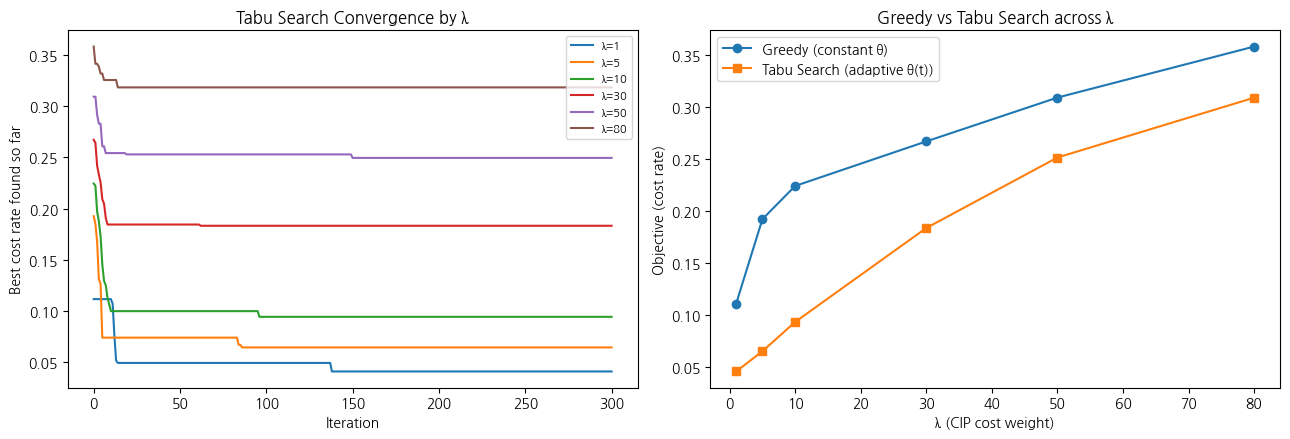

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

ax = axes[0]
for lam in lambdas:
    ax.plot(convergence_curves[lam], label=f'λ={lam}')
ax.set_xlabel('Iteration'); ax.set_ylabel('Best cost rate found so far')
ax.set_title('Tabu Search Convergence by λ')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(res_df['lambda'], res_df['greedy_rate'], 'o-', label='Greedy (constant θ)')
ax.plot(res_df['lambda'], res_df['tabu_rate_mean'], 's-', label='Tabu Search (adaptive θ(t))')
ax.set_xlabel('λ (CIP cost weight)'); ax.set_ylabel('Objective (cost rate)')
ax.set_title('Greedy vs Tabu Search across λ')
ax.legend()

plt.tight_layout()
plt.savefig('convergence_and_comparison.png', dpi=130)
plt.show()

### 여기부터 12페이지 넣을 것들

In [12]:
# 기존 tabu search 수정본
def tabu_search_logged(lam, step=0.08, tenure=8, max_iter=300, no_improve_limit=40, init_beta=None, seed=0):
    rng = np.random.default_rng(seed)
    if init_beta is None:
        init_beta = np.array([greedy_baseline(lam)['beta'][0], 0.0, 0.0, 0.0])
    cur = np.array(init_beta, dtype=float)
    cur_obj, _, _, _ = objective(cur, lam)
    best, best_obj = cur.copy(), cur_obj

    tabu = {}
    history = [best_obj]
    no_improve = 0

    # ---- 로깅용 ----
    event_log = []          # 매 iteration의 성격: 'exploit' | 'aspiration' | 'diversify' | 'no_moves'
    diversify_iters = []    # 다변화(랜덤 점프)가 실제로 발동한 iteration 번호
    tabu_blocked_count = 0  # tabu인데 aspiration도 아니라서 기각된 후보 수
    aspiration_count = 0    # tabu인데 aspiration으로 통과된 후보 수
    move_size_log = []      # 이번 iteration에 실제로 받아들여진 이동 크기 ||Δβ||

    for it in range(max_iter):
        moves = []
        for dim in range(4):
            for sign in (+1, -1):
                cand = cur.copy()
                cand[dim] += sign*step
                if not is_feasible(cand):
                    continue
                o, _, _, _ = objective(cand, lam)
                is_tabu = tabu.get((dim, sign), -1) > it
                aspiration = o < best_obj
                if is_tabu and not aspiration:
                    tabu_blocked_count += 1
                    continue
                if is_tabu and aspiration:
                    aspiration_count += 1
                moves.append((o, dim, sign, cand, is_tabu))

        if not moves:
            cand = cur + rng.normal(0, step*3, size=4)
            if is_feasible(cand):
                move_size_log.append(np.linalg.norm(cand - cur))
                cur = cand
                cur_obj, _, _, _ = objective(cur, lam)
            else:
                move_size_log.append(0.0)
            history.append(best_obj)
            event_log.append('no_moves')
            continue

        moves.sort(key=lambda m: m[0])
        o, dim, sign, cand, was_tabu = moves[0]
        move_size_log.append(np.linalg.norm(cand - cur))
        cur, cur_obj = cand, o
        tabu[(dim, -sign)] = it + tenure

        if cur_obj < best_obj - 1e-12:
            best, best_obj = cur.copy(), cur_obj
            no_improve = 0
        else:
            no_improve += 1

        history.append(best_obj)
        event_log.append('aspiration' if was_tabu else 'exploit')

        if no_improve >= no_improve_limit:
            cand = best + rng.normal(0, step*4, size=4)
            if is_feasible(cand):
                cur = cand
                cur_obj, _, _, _ = objective(cur, lam)
            no_improve = 0
            diversify_iters.append(it)
            event_log[-1] = 'diversify'

    loss, cip, t = simulate(best)
    return {'rate': best_obj, 'loss': loss, 'cip': cip, 'time_hours': t, 'beta': best.tolist(),
            'history': history, 'event_log': event_log, 'diversify_iters': diversify_iters,
            'tabu_blocked_count': tabu_blocked_count, 'aspiration_count': aspiration_count,
            'move_size_log': move_size_log}

In [13]:
all_runs = {lam: [tabu_search_logged(lam, step=0.08, tenure=8, max_iter=300, seed=s) for s in range(14)]
            for lam in lambdas}

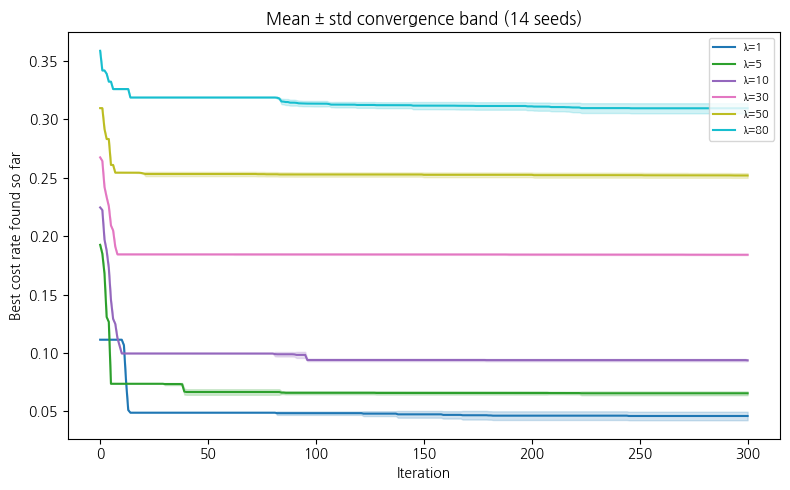

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
colors = plt.cm.tab10(np.linspace(0,1,len(lambdas)))
for lam, c in zip(lambdas, colors):
    hist_matrix = np.array([r['history'] for r in all_runs[lam]])  # (14, 301)
    mean_h, std_h = hist_matrix.mean(0), hist_matrix.std(0, ddof=1)
    x = np.arange(len(mean_h))
    ax.plot(x, mean_h, color=c, label=f'λ={lam}')
    ax.fill_between(x, mean_h-std_h, mean_h+std_h, color=c, alpha=0.2)
ax.set_xlabel('Iteration'); ax.set_ylabel('Best cost rate found so far')
ax.set_title('Mean ± std convergence band (14 seeds)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. Results Summary




In [18]:
res_df.to_csv('optimization_results.csv', index=False)
print("Saved: optimization_results.csv, convergence_and_comparison.png")
res_df_display.round(5)


Saved: optimization_results.csv, convergence_and_comparison.png


,lambda,Greedy Rate,Greedy #CIP,Tabu Rate(mean),Tabu Rate(std),Tabu #CIP(mean),Improve(%),Greedy time(s),"Tabu time(s, mean)"
0,1,0.11137,10,0.04610,0.00364,9.21429,58.60465,0.06375,0.56526
1,5,0.19253,10,0.06552,0.00164,9.00000,65.96647,0.09551,0.52878
2,10,0.22451,9,0.09373,0.00066,9.00000,58.25157,0.05593,0.59737
3,30,0.26733,9,0.18406,0.00044,8.92857,31.15010,0.05777,0.50719
4,50,0.30947,9,0.25184,0.00202,8.07143,18.62394,0.06533,0.59048
5,80,0.35850,5,0.30934,0.00432,5.57143,13.71330,0.05982,0.54651


In [19]:
res_df_display

,lambda,Greedy Rate,Greedy #CIP,Tabu Rate(mean),Tabu Rate(std),Tabu #CIP(mean),Improve(%),Greedy time(s),"Tabu time(s, mean)"
0,1,0.111365,10,0.046100,0.003643,9.214286,58.604647,0.063747,0.565262
1,5,0.192527,10,0.065524,0.001637,9.000000,65.966472,0.095514,0.528784
2,10,0.224512,9,0.093730,0.000665,9.000000,58.251570,0.055930,0.597370
3,30,0.267329,9,0.184056,0.000442,8.928571,31.150098,0.057773,0.507186
4,50,0.309471,9,0.251835,0.002020,8.071429,18.623942,0.065325,0.590475
5,80,0.358505,5,0.309342,0.004323,5.571429,13.713300,0.059824,0.546508


In [20]:
# 실제 보고서에서 정하는 세척 임계치는 SF가 0.9 이하로 떨어졌을 때를 말함.
# 즉, 이 수치를 benchmark로 해서 둘 필요가 있음.
BENCHMARK_RATIO = 0.9

def simulate_benchmark(ratio):
    total_loss, total_cip, total_time = 0.0, 0, 0.0
    for c in cycles:
        idx = cycle_idx[c]
        sf_c = SF[idx]
        ref = cycle_start[c]
        th_c = ratio * ref          # 사이클 시작 SF 대비 고정 비율 임계치 (튜닝 X)
        below = np.where(sf_c < th_c)[0]
        if below.size > 0:
            first = below[0]
            window = slice(0, first + 1)
            T_c = first + 1
            total_cip += 1
        else:
            window = slice(0, len(sf_c))
            T_c = len(sf_c)
        total_loss += np.sum(np.maximum(0.0, ref - sf_c[window]))
        total_time += T_c
    return total_loss, total_cip, total_time

bench_loss, bench_cip, bench_time = simulate_benchmark(BENCHMARK_RATIO)
print(f"Benchmark (0.9×SF0 fixed rule): cip={bench_cip}, loss={bench_loss:.2f}, time={bench_time:.0f}h")

# lambda별 rate 계산 (loss/cip/time은 고정, lambda만 바뀌므로 rate만 재계산)
res_df['benchmark_rate'] = [(bench_loss + lam*bench_cip) / bench_time for lam in res_df['lambda']]
res_df['benchmark_cip'] = bench_cip
res_df['improve_vs_benchmark_pct'] = (res_df['benchmark_rate'] - res_df['tabu_rate_mean']) / res_df['benchmark_rate'] * 100

res_df_display3 = res_df[['lambda','benchmark_rate','greedy_rate','tabu_rate_mean',
                           'benchmark_cip','greedy_cip','tabu_cip_mean','improve_vs_benchmark_pct']]
res_df_display3.columns = ['lambda','Benchmark Rate','Greedy Rate','Tabu Rate(mean)',
                            'Benchmark #CIP','Greedy #CIP','Tabu #CIP(mean)','Improve vs Benchmark(%)']
res_df_display3.round(5)

Benchmark (0.9×SF0 fixed rule): cip=9, loss=757.13, time=4540h


,lambda,Benchmark Rate,Greedy Rate,Tabu Rate(mean),Benchmark #CIP,Greedy #CIP,Tabu #CIP(mean),Improve vs Benchmark(%)
0,1,0.16875,0.11137,0.04610,9,10,9.21429,72.68178
1,5,0.17668,0.19253,0.06552,9,10,9.00000,62.91421
2,10,0.18659,0.22451,0.09373,9,9,9.00000,49.76751
3,30,0.22624,0.26733,0.18406,9,9,8.92857,18.64613
4,50,0.26589,0.30947,0.25184,9,9,8.07143,5.28533
5,80,0.32536,0.35850,0.30934,9,5,5.57143,4.92304


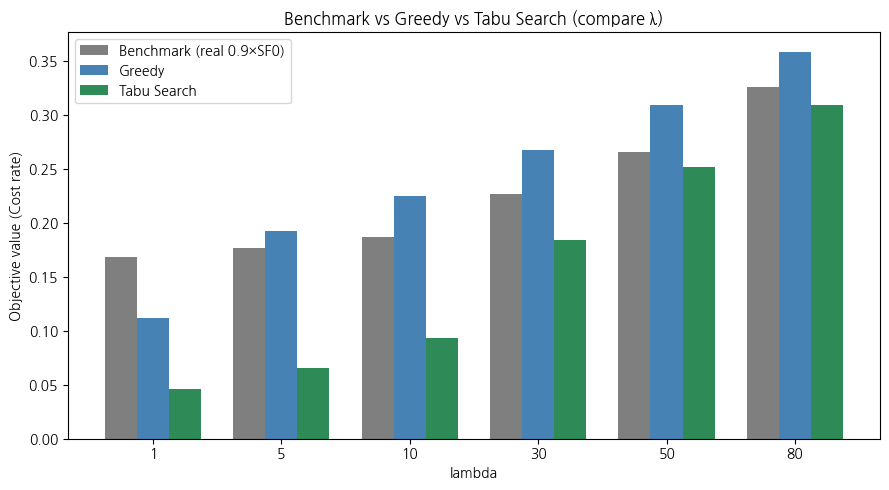

In [21]:
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(res_df))
w = 0.25
ax.bar(x - w, res_df['benchmark_rate'], w, label='Benchmark (real 0.9×SF0)', color='tab:gray')
ax.bar(x,     res_df['greedy_rate'],    w, label='Greedy',   color='steelblue')
ax.bar(x + w, res_df['tabu_rate_mean'], w, label='Tabu Search', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(res_df['lambda'])
ax.set_xlabel('lambda'); ax.set_ylabel('Objective value (Cost rate)')
ax.set_title('Benchmark vs Greedy vs Tabu Search (compare λ)')
ax.legend(); plt.tight_layout(); plt.show()

# β* 해석



In [22]:
# ============================================================
# 8. Extracting the Optimal Adaptive Rule (β* 해석)
# ============================================================

def extract_optimal_rule(lam, n_seeds=14, step=0.08, tenure=8, max_iter=300):
    """주어진 lambda에서 n_seeds번 Tabu Search를 돌려 best rate를 낸 seed의
    beta*를 뽑고, z-score 계수를 원래 단위(TDS ppm, TEMP ℃, Turbidity NTU)로 역변환한다."""
    runs = [tabu_search(lam, step=step, tenure=tenure, max_iter=max_iter, seed=s)
            for s in range(n_seeds)]
    best_run = min(runs, key=lambda r: r['rate'])
    b0, b1, b2, b3 = best_run['beta']

    # z-score 역변환:
    # theta(t) = b0 + b1*TDS_z + b2*TEMP_z + b3*TURB_z
    #          = raw_b0 + raw_bTDS*TDS + raw_bTEMP*TEMP + raw_bTURB*TURB
    raw_bTDS  = b1 / TDS.std()
    raw_bTEMP = b2 / TEMP.std()
    raw_bTURB = b3 / TURB.std()
    raw_b0 = (b0
              - b1*TDS.mean()/TDS.std()
              - b2*TEMP.mean()/TEMP.std()
              - b3*TURB.mean()/TURB.std())

    return {
        'lambda': lam, 'rate': best_run['rate'], 'cip': best_run['cip'],
        'beta_z': [b0, b1, b2, b3],
        'beta_raw': {'intercept': raw_b0, 'TDS_per_ppm': raw_bTDS,
                     'TEMP_per_C': raw_bTEMP, 'TURB_per_NTU': raw_bTURB},
    }

optimal_rules = {}
for lam in lambdas:  # 이미 정의된 [1, 5, 10, 30, 50, 80]
    res = extract_optimal_rule(lam)
    optimal_rules[lam] = res
    print(f"\n===== lambda = {lam} =====")
    print(f"best rate = {res['rate']:.5f}, CIP count = {res['cip']}")
    b = res['beta_z']
    print(f"beta (z-scored)  : b0={b[0]:.3f}, b_TDS={b[1]:.3f}, "
          f"b_TEMP={b[2]:.3f}, b_TURB={b[3]:.3f}")
    raw = res['beta_raw']
    print(f"theta(t) [raw units] = {raw['intercept']:.4f} "
          f"+ ({raw['TDS_per_ppm']:.5f})*TDS "
          f"+ ({raw['TEMP_per_C']:.5f})*TEMP "
          f"+ ({raw['TURB_per_NTU']:.5f})*Turbidity")


===== lambda = 1 =====
best rate = 0.03912, CIP count = 10
beta (z-scored)  : b0=5.138, b_TDS=0.082, b_TEMP=-0.300, b_TURB=0.021
theta(t) [raw units] = 5.3593 + (0.00079)*TDS + (-0.03828)*TEMP + (0.09844)*Turbidity

===== lambda = 5 =====
best rate = 0.06145, CIP count = 9
beta (z-scored)  : b0=5.171, b_TDS=0.160, b_TEMP=-0.273, b_TURB=0.013
theta(t) [raw units] = 5.0473 + (0.00154)*TDS + (-0.03483)*TEMP + (0.06023)*Turbidity

===== lambda = 10 =====
best rate = 0.09216, CIP count = 9
beta (z-scored)  : b0=5.156, b_TDS=0.139, b_TEMP=-0.296, b_TURB=-0.006
theta(t) [raw units] = 5.2083 + (0.00134)*TDS + (-0.03785)*TEMP + (-0.02656)*Turbidity

===== lambda = 30 =====
best rate = 0.18315, CIP count = 9
beta (z-scored)  : b0=4.975, b_TDS=0.075, b_TEMP=-0.279, b_TURB=0.013
theta(t) [raw units] = 5.2033 + (0.00072)*TDS + (-0.03570)*TEMP + (0.06227)*Turbidity

===== lambda = 50 =====
best rate = 0.24671, CIP count = 8
beta (z-scored)  : b0=4.766, b_TDS=0.319, b_TEMP=-0.230, b_TURB=0.036
theta